In [1]:
import os
import cv2
import torch
import numpy as np
import pandas as pd
from torch.utils.data import Dataset, DataLoader
import segmentation_models_pytorch as smp
import albumentations as A
from albumentations.pytorch import ToTensorV2
from tqdm import tqdm

# Ayarlar
DATA_PATH = r"C:\Users\Ayberk\Desktop\Fundus-AVSeg"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
BATCH_SIZE = 4
IMG_SIZE = (512, 512) # Bellek yönetimi için makaledeki gibi yamalamak yerine resize ediyoruz
LEARNING_RATE = 1e-4
EPOCHS = 50

# Sınıf Renkleri (Makale [cite: 86])
# Red: Artery, Blue: Vein, Green: Crossing, White: Uncertain, Black: Background

C:\Users\Ayberk\AppData\Roaming\Python\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
class FundusAVDataset(Dataset):
    def __init__(self, data_path, split_file, transform=None):
        self.data_path = data_path
        self.transform = transform
        
        # Görüntü isimlerini txt dosyasından oku [cite: 151]
        with open(os.path.join(data_path, split_file), 'r') as f:
            self.image_names = [line.strip() for line in f.readlines()]

    def __len__(self):
        return len(self.image_names)

    def __getitem__(self, idx):
        img_name = self.image_names[idx]
        img_path = os.path.join(self.data_path, "images", img_name)
        mask_path = os.path.join(self.data_path, "annotation", img_name)

        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        mask_rgb = cv2.imread(mask_path)
        mask_rgb = cv2.cvtColor(mask_rgb, cv2.COLOR_BGR2RGB)

        # Renkli maskeyi sınıf indekslerine dönüştür [cite: 86, 104]
        mask = np.zeros((mask_rgb.shape[0], mask_rgb.shape[1]), dtype=np.long)
        
        # Renk eşleşmeleri
        mask[(mask_rgb == [255, 0, 0]).all(axis=-1)] = 1 # Arter
        mask[(mask_rgb == [0, 0, 255]).all(axis=-1)] = 2 # Ven
        mask[(mask_rgb == [0, 255, 0]).all(axis=-1)] = 3 # Kesişim (Crossing)
        mask[(mask_rgb == [255, 255, 255]).all(axis=-1)] = 4 # Belirsiz

        if self.transform:
            augmented = self.transform(image=image, mask=mask)
            image = augmented['image']
            mask = augmented['mask']

        return image, mask

In [3]:
train_transform = A.Compose([
    A.Resize(IMG_SIZE[0], IMG_SIZE[1]),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

val_transform = A.Compose([
    A.Resize(IMG_SIZE[0], IMG_SIZE[1]),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

train_ds = FundusAVDataset(DATA_PATH, "training.txt", transform=train_transform)
val_ds = FundusAVDataset(DATA_PATH, "testing.txt", transform=val_transform)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)

In [4]:
model = smp.Unet(
    encoder_name="resnet34",        # Skip connection içeren güçlü encoder
    encoder_weights="imagenet",     # Pretrained ağırlıklar
    in_channels=3,                  # RGB giriş
    classes=5,                      # Background + 4 Sınıf 
).to(DEVICE)

# Arter ve Ven odaklı olduğu için DiceLoss ve CrossEntropy kombinasyonu iyidir
criterion = smp.losses.DiceLoss(mode='multiclass')
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

In [5]:
# --- 5. HÜCRE GÜNCELLEME ---
best_iou = 0.0

for epoch in range(EPOCHS):
    model.train()
    train_loss = 0
    for images, masks in tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}"):
        # DÜZELTME: .long() ekledik
        images, masks = images.to(DEVICE), masks.to(DEVICE).long()
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, masks)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    # Validation kısmında da aynı düzeltmeyi yapıyoruz
    model.eval()
    tp, fp, fn, tn = 0, 0, 0, 0
    with torch.no_grad():
        for images, masks in val_loader:
            # DÜZELTME: .long() ekledik
            images, masks = images.to(DEVICE), masks.to(DEVICE).long()
            outputs = model(images)
            
            preds = torch.argmax(outputs, dim=1)
            stats = smp.metrics.get_stats(preds, masks, mode='multiclass', num_classes=5)
            tp += stats[0]; fp += stats[1]; fn += stats[2]; tn += stats[3]

    current_iou = smp.metrics.iou_score(tp, fp, fn, tn, reduction="macro-imagewise").item()
    print(f"Train Loss: {train_loss/len(train_loader):.4f} | Val IoU: {current_iou:.4f}")

    if current_iou > best_iou:
        best_iou = current_iou
        torch.save(model.state_dict(), "best_fundus_model.pth")
        print("--> Model başarıyla güncellendi ve kaydedildi!")

Epoch 1/50: 100%|██████████| 20/20 [00:20<00:00,  1.05s/it]


Train Loss: 0.8745 | Val IoU: 0.1022
--> Model başarıyla güncellendi ve kaydedildi!


Epoch 2/50: 100%|██████████| 20/20 [00:19<00:00,  1.00it/s]


Train Loss: 0.8402 | Val IoU: 0.1356
--> Model başarıyla güncellendi ve kaydedildi!


Epoch 3/50: 100%|██████████| 20/20 [00:19<00:00,  1.01it/s]


...

Train Loss: 0.3769 | Val IoU: 0.4886


Epoch 49/50: 100%|██████████| 20/20 [00:20<00:00,  1.03s/it]


Train Loss: 0.3805 | Val IoU: 0.4981


Epoch 50/50: 100%|██████████| 20/20 [00:20<00:00,  1.02s/it]


Train Loss: 0.3771 | Val IoU: 0.4913


--- Test Başlatılıyor (Toplam 20 Görüntü) ---


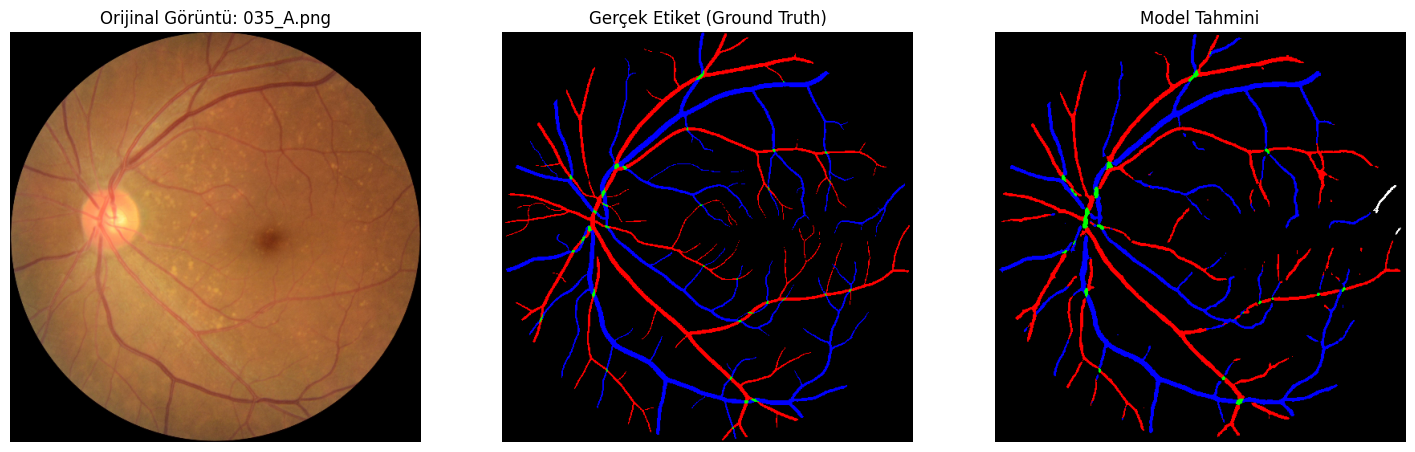

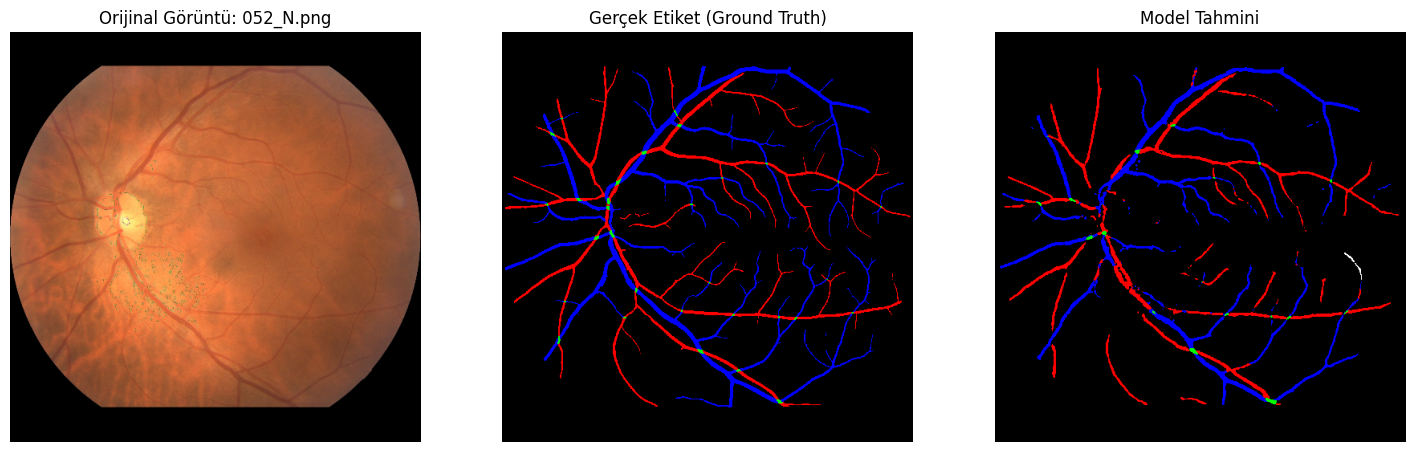

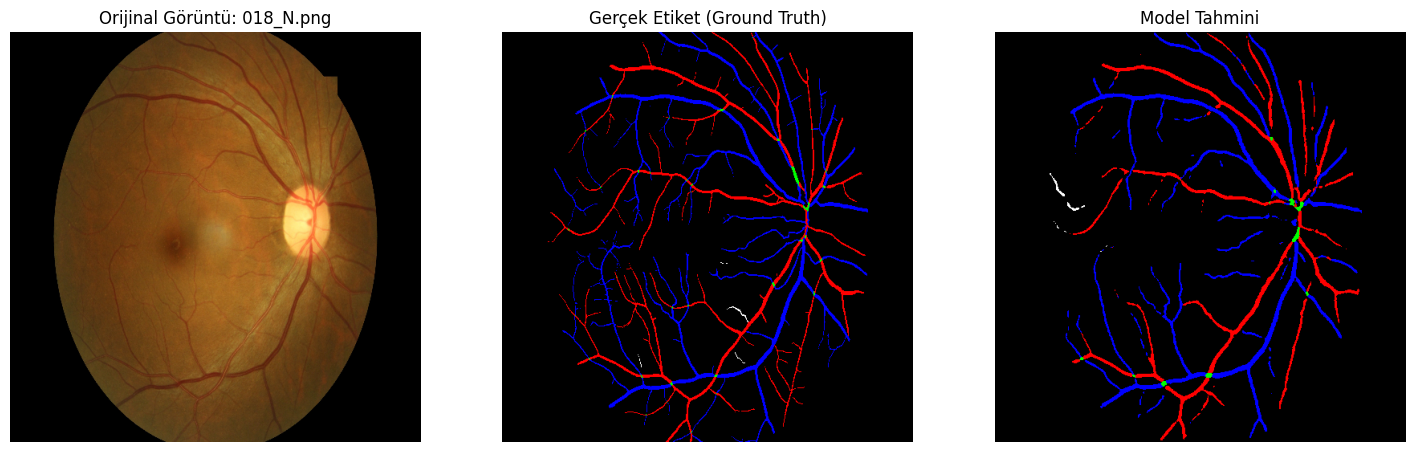

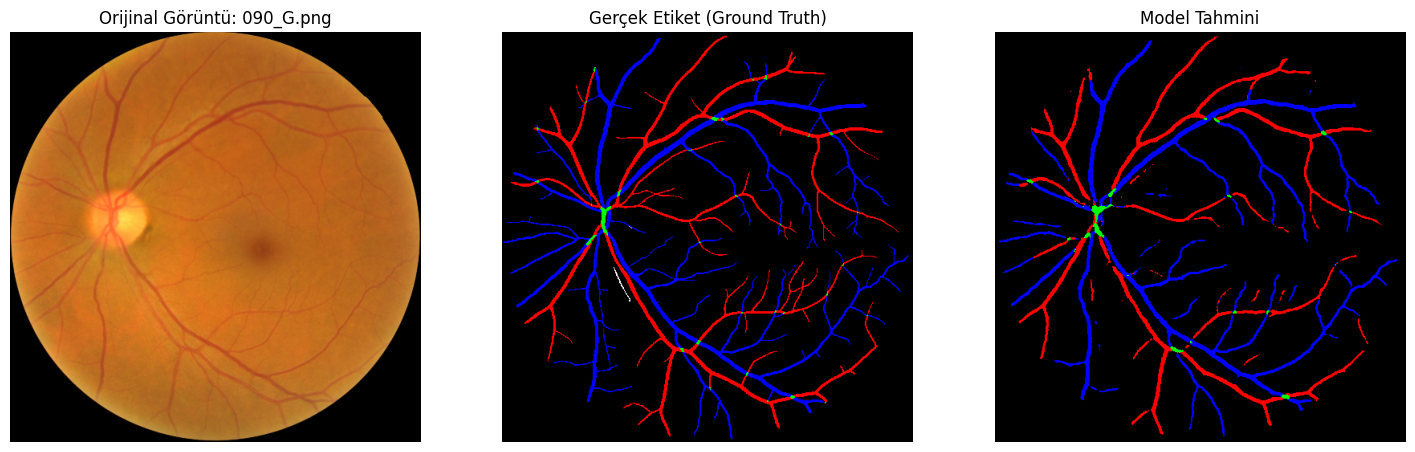

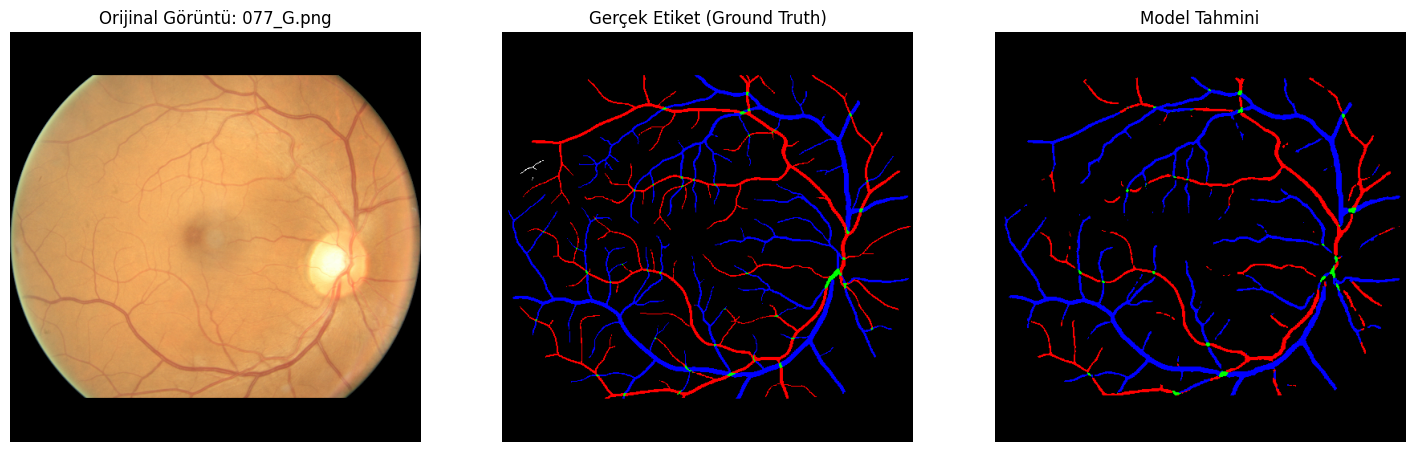


SINIF BAZLI TEST SONUÇLARI
Background   | IoU: 0.9638 | Dice: 0.9815
Artery       | IoU: 0.5780 | Dice: 0.7326
Vein         | IoU: 0.6313 | Dice: 0.7740
Crossing     | IoU: 0.2722 | Dice: 0.4279
Uncertain    | IoU: 0.0518 | Dice: 0.0984
------------------------------
GENEL ORTALAMA | IoU: 0.4994 | Dice: 0.6029


In [6]:
import torch
import matplotlib.pyplot as plt
import numpy as np
from torch.utils.data import DataLoader

# 1. Renk Haritası Tanımlama (Makale Standartları)
#
class_colors = {
    0: [0, 0, 0],       # Background (Siyah)
    1: [255, 0, 0],     # Artery (Kırmızı)
    2: [0, 0, 255],     # Vein (Mavi)
    3: [0, 255, 0],     # Crossing (Yeşil)
    4: [255, 255, 255]  # Uncertain (Beyaz)
}

def mask_to_rgb(mask):
    h, w = mask.shape
    rgb = np.zeros((h, w, 3), dtype=np.uint8)
    for cls, color in class_colors.items():
        rgb[mask == cls] = color
    return rgb

# 2. Modeli Yükle
model.load_state_dict(torch.load("best_fundus_model.pth"))
model.eval()

# Tüm test verisini içeren loader (Batch size 1 görselleştirme için idealdir)
test_loader = DataLoader(val_ds, batch_size=1, shuffle=False)

# Metrik Takibi İçin Listeler
all_tp, all_fp, all_fn, all_tn = [], [], [], []
class_names = ["Background", "Artery", "Vein", "Crossing", "Uncertain"]

print(f"--- Test Başlatılıyor (Toplam {len(test_loader)} Görüntü) ---")

with torch.no_grad():
    for i, (image, mask) in enumerate(test_loader):
        image, mask = image.to(DEVICE), mask.to(DEVICE).long()
        output = model(image)
        pred = torch.argmax(output, dim=1)

        # Metrikleri Biriktir
        stats = smp.metrics.get_stats(pred, mask, mode='multiclass', num_classes=5)
        all_tp.append(stats[0]); all_fp.append(stats[1])
        all_fn.append(stats[2]); all_tn.append(stats[3])

        # Görselleştirme (İlk 5 görüntüyü veya hepsini gösterebilirsin)
        if i < 5: # Ekranı çok doldurmaması için sınırlandırabilirsin
            img_np = image[0].cpu().permute(1, 2, 0).numpy()
            # Denormalize (Visualization için)
            img_np = (img_np * [0.229, 0.224, 0.225]) + [0.485, 0.456, 0.406]
            img_np = np.clip(img_np, 0, 1)

            gt_rgb = mask_to_rgb(mask[0].cpu().numpy())
            pred_rgb = mask_to_rgb(pred[0].cpu().numpy())

            plt.figure(figsize=(18, 6))
            plt.subplot(1, 3, 1)
            plt.title(f"Orijinal Görüntü: {val_ds.image_names[i]}")
            plt.imshow(img_np)
            plt.axis('off')

            plt.subplot(1, 3, 2)
            plt.title("Gerçek Etiket (Ground Truth)")
            plt.imshow(gt_rgb)
            plt.axis('off')

            plt.subplot(1, 3, 3)
            plt.title("Model Tahmini")
            plt.imshow(pred_rgb)
            plt.axis('off')
            plt.show()

# 3. Nihai Metrik Hesaplama (Tüm Test Seti Ortalaması)
#
tp = torch.cat(all_tp); fp = torch.cat(all_fp); fn = torch.cat(all_fn); tn = torch.cat(all_tn)

iou_per_class = smp.metrics.iou_score(tp, fp, fn, tn, reduction="macro")
dice_per_class = smp.metrics.f1_score(tp, fp, fn, tn, reduction="macro")

# Sınıf Bazlı Sonuçları Yazdır
#
print("\n" + "="*30)
print("SINIF BAZLI TEST SONUÇLARI")
print("="*30)
for idx, name in enumerate(class_names):
    # Her sınıfın kendi indeksindeki değerleri al
    c_tp = tp[:, idx].sum(); c_fp = fp[:, idx].sum(); c_fn = fn[:, idx].sum(); c_tn = tn[:, idx].sum()
    
    c_iou = (c_tp / (c_tp + c_fp + c_fn + 1e-7)).item()
    c_dice = (2 * c_tp / (2 * c_tp + c_fp + c_fn + 1e-7)).item()
    
    print(f"{name:12} | IoU: {c_iou:.4f} | Dice: {c_dice:.4f}")

print("-" * 30)
print(f"GENEL ORTALAMA | IoU: {iou_per_class:.4f} | Dice: {dice_per_class:.4f}")
print("=" * 30)